# Введение во временные ряды

Временной ряд — это последовательность наблюдений, упорядоченных по времени (*обычно* с равными интервалами между наблюдениями):

$ts = { y_{1}, y_{2}, …, y_{t} }$

🦋 **Какие примеры временных рядов вы можете привести?**

## Подготовка

In [ ]:
# Работа с данными
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import plotly.express as px

# Тесты на стационарность
from statsmodels.tsa.stattools import adfuller, kpss

# Тест на автокорреляцию
from statsmodels.stats.diagnostic import acorr_ljungbox

In [ ]:
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

In [ ]:
def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)

## Данные

Рассмотрим датасет с почасовыми значениями влажности в различных городах США. Скачать данные можно [здесь](https://github.com/tirthajyoti/Deep-learning-with-Python/blob/master/Data/historical-hourly-weather-data/humidity.csv).

Данные представлены за период с 2012-10-01 по 2017-11-30.

In [ ]:
humidity = pd.read_csv('humidity.csv')
humidity.head()

In [ ]:
humidity.shape

Самая простая визуализация (с встроенным matplotlib):

In [ ]:
humidity["Las Vegas"].plot(figsize=(15, 3))
plt.title('Humidity in Las Vegas over time (hourly frequency)')
plt.show()

## Работа с датами

### Timestamp и Period

**Что такое Timestamp и Period, и чем они полезны?**

*Timestamp* используются для представления конкретного момента времени.

*Period* представляют интервал времени. *Period* можно применять, чтобы проверить, попадает ли событие в заданный интервал.

Эти два типа можно преобразовывать друг в друга.

In [ ]:
# Создание Timestamp
timestamp = pd.Timestamp(2017, 1, 1, 4, 20, 42)
timestamp

In [ ]:
# Создание Period
period = pd.Period('2017-01-01')
print(period.start_time, '\n', period.end_time)

In [ ]:
# Проверяем, попадает ли заданный Timestamp в Period
period.start_time < timestamp < period.end_time

In [ ]:
# Преобразуем Timestamp в Period
period_from_tstamp = timestamp.to_period(freq='h')
period_from_tstamp

In [ ]:
# Преобразуем Period в Timestamp
tstamp_from_period = period.to_timestamp(freq='h', how='start') # start означает начало периода
tstamp_from_period

### date_range

**Что такое date_range и чем он полезен?**

*date_range* — это метод, который возвращает DatetimeIndex с фиксированной частотой — "список" дат. Он полезен при создании собственного временного признака для уже имеющихся данных или при организации данных вокруг созданного временного признака.

In [ ]:
# Создаём DatetimeIndex с дневной частотой
dr1 = pd.date_range(start='1/1/18', end='1/9/19', freq='D')
dr1

In [ ]:
# Создаём DatetimeIndex с месячной частотой
dr2 = pd.date_range(start='1/1/18', end='1/1/19', freq='MS') # MS — начало месяца, ME — конец
dr2

In [ ]:
# Создаём DatetimeIndex без указания даты начала, задавая количество периодов
dr3 = pd.date_range(end='1/4/2014', periods=8)
dr3

In [ ]:
# Создаём DatetimeIndex, задавая дату начала, дату окончания и количество периодов
dr4 = pd.date_range(start='2013-04-24', end='2014-11-27', periods=3)
dr4

### to_datetime

*pandas.to_datetime()* используется для преобразования аргументов в объект Timestamp.


In [ ]:
d = pd.to_datetime('01-01-2017 4:20:42.42', format='%d-%m-%Y %H:%M:%S.%f') # format обычно не требуется, но иногда бывает полезен
d

Мы также можем преобразовывать DataFrame с помощью *pd.to_datetime*.

In [ ]:
# Создадим df
df = pd.DataFrame({'year': [2015, 2016], 'month': [2, 3], 'day': [4, 5]})
df

Примечание: Timestamp — это расширение над datetime64 с доп. функциями:
datetime64[ns] << Timestamp

In [ ]:
# Преобразуем в datetime
df = pd.to_datetime(df)
df

## Фильтрация по дате

Отфильтруем наш датасет с влажностью за 2016 год.

In [ ]:
humidity.head()

In [ ]:
humidity.dtypes[:3]

🦋 **Как отфильтровать 2016 год?**


In [ ]:
# <your code here>

Считаем данные заново для более удобной фильтрации в будущем: используем параметр *parse_dates*.

In [ ]:
humidity = pd.read_csv('humidity.csv', index_col='datetime', parse_dates=['datetime'])
humidity.head()

In [ ]:
humidity[humidity.index.year == 2016]

In [ ]:
humidity.loc['2016-01-01':'2016-12-31']

# Визуализация с помощью matplotlib

[Matplotlib](https://matplotlib.org/) — это библиотека Python для построения визуализаций на данных. Она предоставляет широкий набор инструментов для создания линейных графиков, гистограмм, диаграмм рассеяния и других типов графиков. Широко используется в задачах анализа данных и машинного обучения.

## Предобработка

In [ ]:
humidity.head()

In [ ]:
humidity.isna().sum()

Заполним пропуски.

In [ ]:
humidity = humidity.iloc[1:] # удаляем первую пустую строку
humidity = humidity.fillna(method='ffill') # заполняем пропуски последним известным значением
humidity.head()

In [ ]:
# Проверим, остались ли пропуски

humidity.isna().sum().sum()

Давайте подробнее изучим влажность в Лас-Вегасе.

In [ ]:
humidity_la = humidity["Las Vegas"]
humidity_la.head()

In [ ]:
humidity_la.plot(figsize=(15, 3))
plt.title('Humidity in Las Vegas over time (hourly frequency)')
plt.show()

## Добавление вертикальных и горизонтальных линий

In [ ]:
# Вспомним, как выглядят данные
humidity_la

In [ ]:
ax = humidity_la.plot(figsize=(15, 3))
ax.set_xlabel('date')
ax.set_ylabel('humidity (%)')
ax.axvline('2016-01-01', color='red', linestyle='--')
ax.axhline(17, color='yellow', linestyle='--')
ax.axhline(45, color='yellow', linestyle='--')

## Resampling (изменение гранулярности)

**Upsampling** — временной ряд переводится с более низкой частоты на более высокую (например, с месячной на дневную). Это подразумевает заполнения или интерполяции пропусков.

**Downsampling** — временной ряд переводится с более высокой частоты на более низкую (например, с дневной на месячную). Это подразумевает агрегацию существующих данных.

Метод *asfreq* — просто изменяет частоту, пропуская или добавляя значения (добавление задаётся параметром *method*).

In [ ]:
humidity_la.asfreq('D', method='bfill').head() # bfill — заполняет первым значением

*resample* — изменяет частоту с помощью агрегаций.

Давайте продолжим работать с данными в дневной гранулярности.

In [ ]:
humidity_la = humidity_la.resample('D').mean()

In [ ]:
humidity_la.plot(figsize=(15, 3))
plt.title('Humidity in Las Vegas over time (mean daily frequency)')
plt.show()

## Оконные функции

Оконные функции помогают сгладить данные. Сглаживание временного ряда применяют, чтобы уменьшить краткосрочные колебания и выявить более устойчивые тренды.

Реальные данные часто содержат шум — случайные колебания, которые скрывают основные закономерности. Методы сглаживания, например скользящее среднее, снижают шум, делают данные более интерпретируемыми и подчёркивают сезонные и долгосрочные изменения.

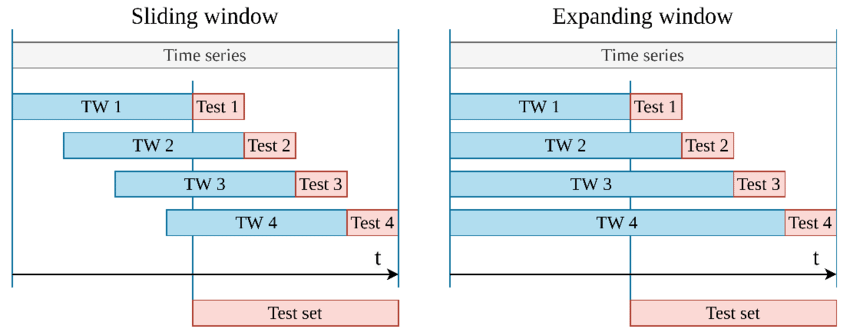

*Expanding window average* (расширяющееся окно с усреднением) полезно для отслеживания накопительных трендов во времени. В отличие от окна фиксированной ширины оно постоянно обновляется по мере поступления новых данных:

${EWA}_t = \frac{1}{T} \sum_{i=1}^{T} y_{i}$, где $T$ — общее число наблюдений.

In [ ]:
humidity_la_expanding = humidity_la.expanding().mean()

In [ ]:
humidity_la.plot(color='silver',figsize=(15, 3))
humidity_la_expanding.plot(color='red')
plt.title('Humidity in Las Vegas over time (mean daily frequency)')
plt.show()

Видно, что изначальные данные очень волатильны. *Smoothing moving average* (скользящее окно с усреднением) усредняет значения в окне, уменьшая колебания:

${SMA}_t = \frac{1}{k} \sum_{i=t-k+1}^{T} y_{i}$, где $T$ — общее число наблюдений, $k$ — размер окна.

Сгладим наш датафрейм скользящим окном с шириной в 7 дней.

In [ ]:
humidity_la_smoothed = humidity_la.rolling(window=7).mean()

In [ ]:
humidity_la.plot(color='silver',figsize=(15, 3))
humidity_la_smoothed.plot(color='red')
plt.title('Humidity in Las Vegas over time (mean daily frequency)')
plt.show()

Колебания всё ещё заметны. Сгладим данные с шириной окна 4 недели.

In [ ]:
humidity_la_smoothed = humidity_la.rolling(window=28).mean()

In [ ]:
humidity_la.plot(color='silver',figsize=(15, 3))
humidity_la_smoothed.plot(color='red')
plt.title('Humidity in Las Vegas over time (mean daily frequency)')
plt.show()

🦋 **Предположите, какой размер окна может дать более гладкий временной ряд.**

In [ ]:
humidity_la_smoothed = humidity_la.rolling(window=28*3).mean()

In [ ]:
humidity_la.plot(color='silver',figsize=(15, 3))
humidity_la_smoothed.plot(color='red')
plt.title('Humidity in Las Vegas over time (mean daily frequency)')
plt.show()

## Паттерны временных рядов

Изучим паттерны, которые может содержать временной ряд.

Попробуем найти годовую сезонность.

In [ ]:
# Предполагаем, что 'humidity_la' — DataFrame с индексом datetime и столбцом 'humidity'
# Группируем данные по годам
years = humidity_la.index.year.unique()
fig, axes = plt.subplots(len(years), 1, figsize=(12, 8), sharex=True)

# Строим график для каждого года на отдельном подграфике
for i, year in enumerate(years):
    yearly_data = humidity_la[humidity_la.index.year == year]
    axes[i].plot(yearly_data.index.dayofyear, yearly_data, label=f'{year}')
    axes[i].set_ylabel('Humidity (%)')
    axes[i].legend()
    axes[i].set_title(f'{year}')

# Форматируем ось X для отображения дня и месяца
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d-%m'))

# Устанавливаем общую подпись оси X
plt.xlabel('datetime')
plt.tight_layout()
plt.show()

🦋 **Какие сезонные паттерны вы замечаете?**

Чтобы нагляднее увидеть годовые зависимости, построим все годы на одном графике.

In [ ]:
# Предполагаем, что 'humidity_la' — это Series pandas с индексом datetime
# Извлекаем уникальные годы из индекса
years = humidity_la_smoothed.index.year.unique()

plt.figure(figsize=(12, 6))

# Строим график для каждого года на одном графике
for year in years:
    yearly_data = humidity_la_smoothed[humidity_la_smoothed.index.year == year]
    plt.plot(yearly_data.index.dayofyear, yearly_data, label=f'{year}')

# Форматируем ось X для отображения дня и месяца
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d-%m'))

# Добавляем подписи и легенду
plt.xlabel('day')
plt.ylabel('humidity (%)')
plt.title('Annual humidity')
plt.legend(title='Year')
plt.show()

🦋 **Какие сезонные паттерны вы видите сейчас?**

# Визуализация с помощью plotly.express

[Plotly Express](https://plotly.com/python/plotly-express/) - это высокоуровневая библиотека Python для создания интерактивных визуализаций. Plotly Express широко используется из-за простоты использования, быстрой генерации красивых интерактивных графиков и интеграции с другими инструментами анализа данных. Он идеально подходит для визуализации сложных наборов данных и изучения тенденций интуитивно понятным и интерактивным способом, что делает его отличным выбором для обработки данных и бизнес-аналитики.

In [ ]:
fig = px.line(humidity_la, x=humidity_la.index, y=humidity_la,
              title="Humidity in Las Vegas over time (avg daily frequency)")

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="humidity (%)")
fig.show()

In [ ]:
fig = px.line(title="Humidity in Las Vegas over time (avg daily frequency)")
fig.add_scatter(x=humidity_la.index, y=humidity_la, mode='lines', name='Original Humidity', line=dict(color='silver'))
fig.add_scatter(x=humidity_la_smoothed.index, y=humidity_la_smoothed, mode='lines', name='SMA', line=dict(color='red'))

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="humidity (%)")
fig.show()

In [ ]:
humidity_la_smoothed = humidity_la_smoothed.reset_index()  # сбрасываем индекс, чтобы получить отдельный столбец с датой
humidity_la_smoothed['year'] = humidity_la_smoothed['datetime'].dt.year
humidity_la_smoothed['day_of_year'] = humidity_la_smoothed['datetime'].dt.dayofyear

fig = px.line(humidity_la_smoothed, x='day_of_year', y=humidity_la_smoothed.columns[1],  # df.columns[1] - выбор колонки с Лас-Вегасом
              color='year',  # группировка по годам
              title="Annual humidity",
              labels={'day_of_year': 'day', humidity_la_smoothed.columns[1]: 'humidity (%)'},
              line_group='year')

fig.update_layout(template='plotly_white', width=800, height=500)
fig.show()

## MoM & YoY growth rates (темпы роста)

**Year-over-year (YoY)** and **month-over-month (MoM)** темпы роста являются общепринятыми показателями в финансовой отчетности, поскольку они помогают отслеживать динамику и тренды бизнес-показателей. MoM аналищ позволяет нам увидеть краткосрочные изменения, выявить сезонные колебания и оценить реакцию на недавние бизнес-инициативы. В свою очередь, YoY анализ позволяет провести сравнение с аналогичными периодами предыдущего года, что важно для оценки долгосрочных тенденций. Вместе данные MoM и YoY дают более полное представление о финансовом состоянии компании, помогая принимать обоснованные управленческие решения и вносить стратегические коррективы.

$\text{MoM} = \frac{\text{Значения текущего месяца} - \text{Значения пред. месяца}}{\text{Значения пред. месяца}} \times 100\%$,

что тоже самое, что и:

$\text{MoM} = \left( \frac{\text{Значения текущего месяца}}{\text{Значения пред. месяца}} - 1 \right) \times 100\%
$

🦋 **Преобразуйте "humidity_la" к месячной гранулярности.**

In [ ]:
humidity_monthly = # <your code here>

In [ ]:
fig = px.line(humidity_monthly, x=humidity_monthly.index, y=humidity_monthly,
              title="Humidity in Las Vegas over time (avg daily frequency)")

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="humidity (%)")
fig.show()

In [ ]:
humidity_monthly = pd.DataFrame(humidity_monthly)

На месячной гранулярности MoM могут быть посчитаны через метод *.pct_change()*.

In [ ]:
humidity_monthly['MoM'] = humidity_monthly['Las Vegas'].pct_change() * 100

In [ ]:
humidity_monthly # вы можете рассчитать MoMs вручную - чтобы проверить, все ли правильно :)

Подготовим более удобную таблицу. Такой формат обычно используется для представления финансовых данных о темпах роста.

In [ ]:
humidity_monthly.index = pd.to_datetime(humidity_monthly.index)
humidity_monthly['year'] = humidity_monthly.index.year
humidity_monthly['month'] = humidity_monthly.index.month

# Разверните данные, чтобы получить годы в строках и месяцы в столбцах.
pivot_table = humidity_monthly.pivot_table(index='year', columns='month', values='MoM')


In [ ]:
pivot_table

🦋 **Расчитайте YoY за все года для Нью-Йорка аналогичным способом.**

In [ ]:
humidity_ny = # <your code here>

H -> D -> Y vs H -> Y?

# Характеристики временного ряда

In [ ]:
humidity_la = humidity["Las Vegas"]
humidity_la.head()

## Lags и shifts (сдвиги)

Мы можем сдвигать индекс на желаемое количество периодов. Это полезно при сравнении временного ряда с самим собой в прошлом.

In [ ]:
humidity_la = pd.DataFrame(humidity_la)

In [ ]:
humidity_la['lag_1'] = humidity_la['Las Vegas'].shift(1) # Lag
humidity_la['shift_1'] = humidity_la['Las Vegas'].shift(-1) # Shift
humidity_la

## Max, Min & Mean

In [ ]:
fig = px.line(humidity_la, x=humidity_la.index, y=humidity_la['Las Vegas'],
              title="Humidity in Las Vegas (avg daily frequency)")

fig.add_hline(y=humidity_la['Las Vegas'].mean(), line=dict(color='red', width=2, dash='solid')) # Mean
fig.add_hline(y=humidity_la['Las Vegas'].max(), line=dict(color='green', width=2, dash='solid')) # Max
fig.add_hline(y=humidity_la['Las Vegas'].min(), line=dict(color='orange', width=2, dash='solid')) # Min

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="date")
fig.update_yaxes(title_text="humidity (%)")
fig.show()

## Дисперсия и автоковариация

*Дисперсия* - мера разброса значений относительно среднего значения ряда.

Он показывает, насколько "изменчивым" или разбросанным является ряд. Более высокая дисперсия указывает на большие колебания значений, в то время как более низкая дисперсия указывает на большую согласованность или стабильность ряда.

In [ ]:
# Посчитаем через numpy
variance = np.var(humidity_la['Las Vegas'], axis=0, ddof=1) #ddof - для N-1 в знаменателе - поправка Бесселя
print(variance)

# Посчитаем вручную
mean = np.mean(humidity_la['Las Vegas'])
variance = np.sum((humidity_la['Las Vegas'] - mean)**2) / (len(humidity_la['Las Vegas'])-1) # N-1 - поправка Бесселя
variance

*Автоковариация* - измеряет взаимосвязь между значениями ряда в разные моменты времени. Для временных рядов автоковариация особенно важна — она показывает взаимосвязь между рядом и его пред. значениями.

Например, ковариация с запаздыванием k показывает взаимосвязь между:y[t] и y[t-k].


In [ ]:
def auto_covariance(y, lag=1):
    # Посчитаем среднее
    mu = np.mean(y)
    y_centered = y - mu

    # Lags
    y1 = y_centered[lag:]  # Сокращенный ряд
    y2 = y_centered[:-lag] # Сокращенный ряд лагов

    # Итоговый расчет
    covariance = np.sum(y1 * y2) / (len(y)-1)

    return covariance

lag1_cov = auto_covariance(humidity_la['Las Vegas'], lag=1)  # автоковариация с лагом 1
print(lag1_cov)

lag2_cov = auto_covariance(humidity_la['Las Vegas'], lag=2)
print(lag2_cov)

## Стационарность

Стационарный временной ряд - это такой, статистические свойства которого, такие как среднее значение, дисперсия, автокорреляция (нормализованная автоковариация) и т.д., постоянны во времени:
$E(y_t) = \mu < \infty$

$var(y_t) = E((y_t - \mu)^2) = \gamma_0$

$cov(y_t, y_{t-k}) = E\{(y_t - \mu)(y_{t-k} - \mu)\} = \gamma_k$

* Сильная стационарность: это стохастический процесс, безусловное совместное распределение вероятностей которого не меняется при сдвиге во времени. Следовательно, такие параметры, как среднее значение и дисперсия, также не меняются со временем.
* Слабая стационарность: это процесс, при котором среднее значение, дисперсия и автокорреляция остаются постоянными на протяжении всего времени.

Стационарность важна, поскольку нестационарные ряды имеют слишком много параметров, которые необходимо учитывать при моделировании временных рядов.

In [ ]:
super_stationary = [] # стационарный
stationary = [] # стационарный
nonstationary_trend = [] # нестационарный из-за тренда
nonstationary_seasonality = [] # нестационарный из-за сезонности
nonstationary_var = [] # нестационарный из-за дисперсии

for i in range(1000):
    if i == 0:
        super_stationary.append(np.random.normal(loc = 0, scale = 1, size = 1))
    else:
        super_stationary.append(1 + 0.5*super_stationary[i-1] + np.random.normal(loc = 0, scale = 1, size = 1))

for i in range(1000):
    if i == 0:
        stationary.append(np.random.normal(loc = 0, scale = 1, size = 1))
    else:
        stationary.append(1 + 0.99*stationary[i-1] + np.random.normal(loc = 0, scale = 1, size = 1))

for i in range(1000):
    if i == 0:
        nonstationary_trend.append(np.random.normal(loc = 0, scale = 1, size = 1))
    else:
        nonstationary_trend.append(1 + nonstationary_trend[i-1] + np.random.normal(loc = 0, scale = 1, size = 1))

for i in range(1000):
    if i == 0:
        nonstationary_seasonality.append(np.random.normal(loc=0, scale=1, size=1))
    else:
        # Сезонная компонента: синусоида с периодом=500
        seasonal_component = 10 * np.sin(2 * np.pi * i / 500)
        nonstationary_seasonality.append(1 + 0.5*nonstationary_seasonality[i-1] + seasonal_component + np.random.normal(loc=0, scale=1, size=1))

for i in range(1000):
    if i == 0:
        nonstationary_var.append(np.random.normal(loc=0, scale=1, size=1))
    else:
        # Растущая дисперсия: шум линейно увеличивается со временем
        variance = 1 + 0.1 * i
        nonstationary_var.append(1 + 0.5*nonstationary_var[i-1] + np.random.normal(loc=0, scale=variance, size=1))

In [ ]:
timeseries = [super_stationary, stationary, nonstationary_trend, nonstationary_seasonality, nonstationary_var]

fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(10, 8), sharex=True)

for i, ts in enumerate(timeseries):
    axs[i].plot(pd.Series(ts), label=f'TS {i+1}')
    axs[i].set_title(f'TS {i+1}')

plt.tight_layout()
plt.show()

### Augmented Dickey-Fuller (ADF) тест

Представьте, что наш временной ряд может быть описан с помощью модели:
$y_t = \alpha \cdot y_{t-1} + \varepsilon_t$

Если $\alpha$ = 1, то говорят о наличии *unit root* (единичный корень).

Если $\alpha$ < 1 (напр., 0.5), временной ряд имеет тенденцию возвращаться к среднему значению. Это похоже на качели — чем дальше они движутся от центра, тем сильнее откат.

Если $\alpha$ = 1 (единичный корень есть), каждое новое значение = предыдущее значение + случайный шок. Временной ряд может "блуждать" куда угодно. Он как пьяница — каждый шаг в случайном направлении, и мы можем оказаться далеко от того места, откуда начали => ** Временной ряд не является стационарным **.

**ADF тест** проверяет наличие *единичного корня*.

H(0): Есть единичный корень (временной ряд не стационарный).

H(A): Нет единичного корня (временной ряд стационарный).

**Если нулевую гипотезу можно отвергнуть, то можно сделать вывод, что временной ряд является стационарным.**

Существует два способа отклонить нулевую гипотезу:

С одной стороны, нулевая гипотеза может быть отклонена, если значение p-value ниже установленного уровня значимости. Уровень значимости по умолчанию берут равным 5%.

* <font color='red'>**p-value > уровня значимости (по умолчанию: 0.05)**</font>: Не удается отклонить нулевую гипотезу H(0), есть едичный корень, и временной ряд <font color='red'>не стационарный</font>.
* <font color='green'>**p-value <= уровня значимости (по умолчанию: 0.05)**</font>: Можно отклонить нулевую гипотезу H(0), нет единичного корня, и временной ряд <font color='green'>стационарный</font>.
    
С другой стороны, нулевая гипотеза может быть отвергнута, если тестовая статистика меньше критического значения.
* <font color='red'>**ADF статистика > критического значения**</font>: Не удается отклонить нулевую гипотезу H(0), есть едичный корень, и временной ряд <font color='red'>не стационарный</font>.
* <font color='green'>**ADF статистика <= критического значения**</font>: Можно отклонить нулевую гипотезу H(0), нет единичного корня, и временной ряд <font color='green'>стационарный</font>.

In [ ]:
adf_test(stationary)

<font color='green'>**p-value <= уровня значимости (по умолчанию: 0.05)**</font> => мы отклоняем нулевую гипотезу, и наш ряд - стационарный!

### Kwiatkowski-Phillips-Schmidt-Shin (KPSS) тест


Представьте, что наш временной ряд может быть описан с помощью модели:

$y_t = \beta_{t} + r_{t} + \varepsilon_t$, где $r_{t} = r_{t-1} + u_{t}$ - *случайное блуждание*, $\beta_{t}$ - направленный тренд.


H(0): Временной ряд стационарный.

H(A): Временной ряд не стационарный.

**Если нулевую гипотезу отвергнуть нельзя, то можно сделать вывод, что временной ряд является стационарным.**

Нулевая гипотеза не может быть отвергнута, если значение p превышает установленный уровень значимости. Уровень значимости по умолчанию равен 5%.

* <font color='green'>**p-value > уровня значимости (по умолчанию: 0.05)**</font>: Не удается отклонить нулевую гипотезу H(0), и временной ряд <font color='green'>стационарный</font>.
* <font color='red'>**p-value <= уровня значимости (по умолчанию: 0.05)**</font>: Можно отклонить нулевую гипотезу H(0), временной ряд<font color='red'>не стационарный</font>.

С другой стороны, нулевая гипотеза может быть отвергнута, если тестовая статистика меньше критического значения.
* <font color='red'>**KPSS статистика > критического значения**</font>: Можно отклонить нулевую гипотезу H(0), временной ряд <font color='red'>не стационарный</font>.
* <font color='green'>**KPSS статистика <= критического значения**</font>: Не удается отклонить нулевую гипотезу H(0), и временной ряд <font color='green'>стационарный</font>.

In [ ]:
kpss_test(stationary)

Упс!  <font color='red'>**p-value <= уровня значимости (по умолчанию: 0,05)**</font> => мы отклоняем нулевую гипотезу, и наш ряд - не стационарный!

Теперь о мощности теста KPSS. Мощность теста - это вероятность правильного отклонения нулевой гипотезы, если она ложна.

**Почему у KPSS может быть низкая мощность:**

**Структурная причина:**
Тест KPSS проверяет нулевую гипотезу стационарности, которая является сложной гипотезой, требующей выполнения множества условий. Доказать, что ряд является стационарным, сложнее, чем то, что он нестационарен.

**Техническая причина:**
Тест основан на регрессионных остатках и требует оценки долгосрочной дисперсии, которая часто бывает неточной при небольших размерах выборки.

**Практические последствия:**
Тест может не выявить нестационарность, особенно если она слабая или размер выборки невелик, что приводит к "ложной стационарности".

**На практике тесты ADF и KPSS часто используются одновременно**:

ADF: H(0) - временной ряд не стационарный

KPSS: H(0) - временной ряд стационарный

Возможные результаты:

* ADF отклоняет H0, KPSS не отклоняет H0 → временной ряд определенно стационарный
* ADF не отклоняет H0, KPSS отклоняет H0 → временной ряд определенно не стационарный
* Оба теста отклоняют H0 → результаты противоречивы
* Оба теста не отклоняют H0 → недостаточно данных

**Если тесты не могут прийти к согласию - лучше применить третий тест (например, тест Phillips–Perron) и определить стационарность большинством голосов ** (если два теста говорят, что временной ряд стационарен - тогда скажите, что он стационарный, и наоборот).

## Автокорреляция

Следующим важным понятием является автокорреляция. На самом деле это очень простое понятие, которое показывает временную корреляцию между значениями. Оно рассчитывается как нормализованная автоковариация:
$$autocorr_{k} = \frac{cov(y_t, y_{t-k})}{var(y_t)}$$  



In [ ]:
def unbiased_variance(y):
    mu = np.mean(y)
    return np.sum((y - mu)**2) / (len(y) - 1)

In [ ]:
def auto_correlation(y, lag=1):
    return auto_covariance(y, lag) / unbiased_variance(y)

In [ ]:
lag1_autocorr = auto_correlation(humidity_la['Las Vegas'], lag=1)  # автокорреляция с лагом
print(lag1_autocorr)

lag2_autocorr = auto_correlation(humidity_la['Las Vegas'], lag=2)
print(lag2_autocorr)

* Автокорреляция* - ключевая характеристика временных рядов, показывающая, насколько ряд зависит от своих прошлых значений. Почему это важно? Потому что это помогает понять природу временных рядов:

* Если автокорреляция быстро исчезает, ряд напоминает белый шум (независимые наблюдения).
* Если он медленно затухает, ряд может быть нестационарным (например, случайное блуждание).
* Если он периодический, ряд может содержать сезонность.

### Ljung-Box тест

Для проверки автокорреляций на разных лагах обычно используется тест Ljung-Box.

Суть теста Ljung-Box заключается в проверке гипотезы о том, что автокорреляции в ряду до лага $m$ равны нулю. Другими словами, он проверяет, является ли ряд "белым шумом" или содержит значимые автокорреляции.

Статистика *теста Ljung-Box* рассчитывается по формуле:

$Q = n (n + 2) \sum \frac{\rho^2(k)}{n - k}$,

где $n$ - размер выборки, $\rho(k)$ - автокорреляция на лаге $k$ ($k$ от 1 до $m$).

**Тест Ljung-Box** проверяет наличие автокорреляций для первых $m$ лагов.

H(0): Первые $m$ автокорреляции равны 0 (ряд не имеет автокорреляции).

H(A): По крайней мере, одна из первых автокорреляций $m$ не равна 0.

**Если нулевая гипотеза может быть отвергнута, мы можем заключить, что временной ряд автокоррелирован.**

Нулевая гипотеза не может быть отвергнута, если значение p превышает установленный уровень значимости. Уровень значимости по умолчанию равен 5%

* **p-значение > уровня значимости (по умолчанию: 0.05)**: Не удается отклонить нулевую гипотезу H(0), временной ряд ** не автокоррелирован**.
* **p-значение <= уровня значимости (по умолчанию: 0.05)**: Отклоняем нулевую гипотезу H(0), временной ряд **автокоррелированя**.

In [ ]:
acorr_ljungbox(humidity_la['Las Vegas'], return_df=True)

🦋 **Рассчитайте ADF, KPSS, тест Юнга-Бокса с использованием того же подхода для Лос-Анджелеса и сделайте предположения о стационарности и автокорреляции**

In [ ]:
humidity_las = # <your code here>

## Выводы

Автокорреляция и стационарность имеют решающее значение для анализа временных рядов, поскольку:

* Автокорреляция помогает выявлять закономерности и зависимости между текущими и прошлыми значениями. Она выявляет тенденции, циклы и сезонность, что позволяет лучше прогнозировать и подгонять модель.

* Стационарность гарантирует верность предположений модели. Если ряд является стационарным, его статистические свойства (среднее значение, дисперсия) не меняются со временем, что упрощает анализ и делает модели, подобные ARIMA, более эффективными для прогнозирования.

Без этого прогнозы могут быть ненадежными, а модели могут давать неточные результаты

# SUM UP

* Обсудили природу временных рядов
* Поработали с различными форматами дат в python
* Поработали с resampling и оконными функциями
* Создали визуализации с помощью matplotlib и plotly.express
* Рассчитали простые статистики: среднее, максимум, минимум, дисперсия, ковариация и лаги
* Обсудили стационарность и тесты на стационарность: ADF, KPSS
* Обсудили автокорреляцию и тест на автокорреляцию: Ljung-Box

Пожалуйста, оставьте свой отзыв [здесь](https://forms.gle/AHyab6LdRtjxGZHT8), давайте сделаем наши уроки более эффективными :)